In [1]:
import os 


os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import ast
import pandas as pd
from sklearn.metrics import f1_score as f1 
from sklearn.metrics import precision_recall_fscore_support as prf
import numpy as np
import pickle as pkl
from scipy.special import softmax


## Obitools

In [ ]:


def can_family(tax_ids,database):

    sub = database[database['taxid_ncbi'].isin(tax_ids)]
    
    family = sub['family'].unique()

    if len(family) > 1:
        return 'NC_'
    return family[0]

acc = []
f1_scrores = []
p_score =[]
r_score =[]

marker = "teleo"

OBI_pred_path = f'Obitools/scripts/results/obi3/{marker}'



for fold in range(1,7):

    print("-----------------")
    database = pd.read_csv(f'Obitools/scripts/data/{marker}/folds/fold_{fold}/train.csv')

    preds = pd.read_csv(OBI_pred_path +f'/fold_{fold}_test_ecotag3.csv', sep="\t")



    preds['BEST_MATCH_IDS'] = preds['BEST_MATCH_IDS'].apply(ast.literal_eval)  # Convert to list of strings
    preds['BEST_MATCH_TAXIDS'] = preds['BEST_MATCH_TAXIDS'].apply(ast.literal_eval) 

    preds['preds_family'] = preds['BEST_MATCH_TAXIDS'].apply(lambda x: can_family(x,database))

    labels = pd.read_csv(f'Obitools/scripts/data/{marker}/folds/fold_{fold}/test.csv')

    classes = labels['family'].unique()

    preds['family_gt'] = labels['family']


    p,r,f,s = prf(preds["family_gt"], preds["preds_family"], average="macro", labels=classes, zero_division=0)
    print(f'Fold {fold} f1: {f}')
    print(f'Fold {fold} precision: {p}')
    print(f'Fold {fold} recall: {r}')

    preds = preds[['family_gt', 'preds_family', 'BEST_IDENTITY','BEST_MATCH_IDS', 'NUC_SEQ']]
    preds.to_csv(OBI_pred_path +f'/fold_{fold}_test_ecotag3_pred.csv', sep="\t", index=False)


    
    tresholds = np.arange(0,0.999,0.0001)
    




-----------------
Fold 1 f1: 0.47465461798636027
Fold 1 precision: 0.4739410382432297
Fold 1 recall: 0.5295737901907528
-----------------
Fold 2 f1: 0.45334882018659667
Fold 2 precision: 0.4435489973857547
Fold 2 recall: 0.5184015261779448
-----------------
Fold 3 f1: 0.468639516330956
Fold 3 precision: 0.46484546611405203
Fold 3 recall: 0.530454500577492
-----------------
Fold 4 f1: 0.4740957234523496
Fold 4 precision: 0.4715387060832812
Fold 4 recall: 0.5344436006828097
-----------------
Fold 5 f1: 0.4604431932210324
Fold 5 precision: 0.45225582727009034
Fold 5 recall: 0.5242502467788803
-----------------
Fold 6 f1: 0.45210807646477363
Fold 6 precision: 0.44843482768147364
Fold 6 recall: 0.5066849733720649


## DNABERT_2

In [4]:
padnas_macro= []
F = []
tresholds = np.arange(0,1,0.001)
for fold in [1,2,3,4,5,6]:
    print("-----------------")
    preds = pd.read_csv(f'DNABert2/experiments/fine_tune_taxa/outputs/teleo_from_mlm_no_cefe/checkpoints/fold_{fold}/predictions.csv')
    
    print("fold",fold)
    p,r,f,s = prf(preds['labels_family'],preds['preds_family'],average='macro', labels=preds['labels_family'].unique(), zero_division=0)
    print('p',p,'r',r,'f',f)

    # read pkl logits for treshold on conf
    logits = pkl.load(open(f'DNABert2/experiments/fine_tune_taxa/outputs/teleo_from_mlm_no_cefe/checkpoints/fold_{fold}/predictions.pkl', 'rb'))  

    logits_preds_family = logits['preds'][1] # size : (n_samples, n_classes)
    probas = softmax(logits_preds_family, axis=1)  # (n_samples, n_classes)
    prf_scores_tresh = np.zeros((len(tresholds), 3))  # to store precision, recall, f1 for each treshold

    #find the best threshold
    for i,treshold in enumerate(tresholds):


        preds_family = probas.argmax(axis=1)

        preds_family[probas.max(axis=1) < treshold] =  -1 #None
        # print conut filtered predictions
        #print('count filtered predictions', np.sum(preds_family == -1))

        p,r,f,s = prf(preds['labels_family'], preds_family, average='macro', labels=preds['labels_family'].unique(), zero_division=0)
        prf_scores_tresh[i, 0] = p
        prf_scores_tresh[i, 1] = r
        prf_scores_tresh[i, 2] = f
 
    # find the best treshold
    arg_max = np.argmax(prf_scores_tresh[:,2])
    best_treshold = tresholds[arg_max]
    print('best treshold', best_treshold)
    print('best f1', np.max(prf_scores_tresh[:,2]) )
    print('best precision', prf_scores_tresh[arg_max,0])
    print('best recall', prf_scores_tresh[arg_max,1])



-----------------
fold 1
p 0.4642533434341877 r 0.55789263076207 f 0.4836824647697926
best treshold 0.535
best f1 0.49727007501176573
best precision 0.4874424034866
best recall 0.5507108691685436
-----------------
fold 2
p 0.4481972977970539 r 0.5577167386831203 f 0.4658507572767918
best treshold 0.585
best f1 0.4964503737953986
best precision 0.49875898846768807
best recall 0.5432106721269999
-----------------
fold 3
p 0.4796223957146761 r 0.5675838102955517 f 0.4911660270706371
best treshold 0.67
best f1 0.5080421069774129
best precision 0.5100166779660261
best recall 0.5558014104354925
-----------------
fold 4
p 0.47466540951553826 r 0.5656663083742823 f 0.4893774999603046
best treshold 0.622
best f1 0.5050346094019454
best precision 0.5008340535028957
best recall 0.5613829593757683
-----------------
fold 5
p 0.45564516147997575 r 0.5616006830912543 f 0.47518455491297984
best treshold 0.596
best f1 0.49037383493475994
best precision 0.48141091473134817
best recall 0.5526699896017373

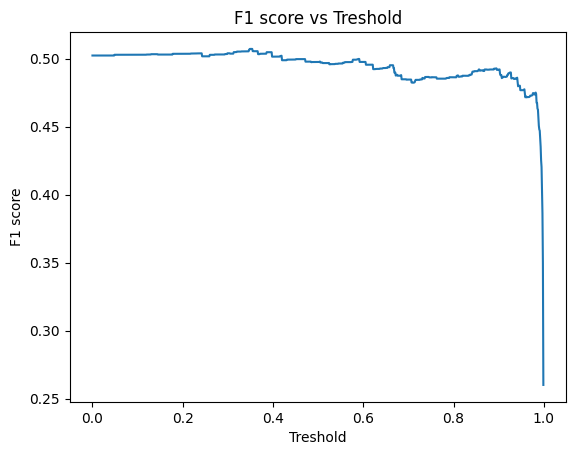

In [6]:
import matplotlib.pyplot as plt

plt.plot(tresholds, prf_scores_tresh[:,2])
plt.xlabel('Treshold')
plt.ylabel('F1 score')
plt.title('F1 score vs Treshold')
plt.show()

## MMSeq2


In [13]:

for fold in [1,2,3,4,5,6]:

    preds_df = pd.read_csv(f'MMseqs2/result/teleov2_no_cefe/folds/fold_{fold}/tax_out/tax_out_lca.tsv', sep="\t", header=None)
    ground_truth = pd.read_csv(f'MMseqs2/teleov2_no_cefe/folds/fold_{fold}/test.csv')
    print("====================")
    print("fold",fold)

    preds_df[0] = preds_df[0].apply(lambda x: x.split('_')[-1]) # remove the prefix

    p,r,f,s = prf(preds_df[3],preds_df[0],average='micro',labels=ground_truth['family'].unique(),zero_division=0)
    print('p',p,'r',r,'f',f)

    


fold 1
p 0.5507399577167019 r 0.6504369538077404 f 0.596451058958214
fold 2
p 0.5764006791171478 r 0.6729435084241824 f 0.6209419295839049
fold 3
p 0.6085011185682326 r 0.6974358974358974 f 0.6499402628434886
fold 4
p 0.6358325219084713 r 0.7279821627647715 f 0.6787941787941788
fold 5
p 0.5704286964129484 r 0.6559356136820925 f 0.6102012166588676
fold 6
p 0.5528364849833148 r 0.637997432605905 f 0.5923718712753278


# Bertax

fold 1
p 0.45403459343339597 r 0.5532991440287252 f 0.4627236040344873
best treshold 0.38
best f1 0.4789036925192197
best precision 0.5041969908159191
best recall 0.5248711706271235
fold 2
p 0.4643986590454552 r 0.5359531666517366 f 0.45509217778229755
best treshold 0.317
best f1 0.4741037266584141
best precision 0.5031613884049905
best recall 0.5219120950789635
fold 3
p 0.457461893326432 r 0.5420774998570036 f 0.4611356780239687
best treshold 0.437
best f1 0.4791658237506381
best precision 0.49381703588881215
best recall 0.5306399543723306
fold 4
p 0.45172377401331654 r 0.5489719781456238 f 0.4560562187414709
best treshold 0.626
best f1 0.4814016953283547
best precision 0.5262625874295298
best recall 0.49956011189151855
fold 5
p 0.4270265177983857 r 0.5317081810032999 f 0.4344932250597088
best treshold 0.449
best f1 0.45912435743578034
best precision 0.4869099399065298
best recall 0.4947887651360578
fold 6
p 0.4799044567207883 r 0.5424413876472223 f 0.4711977555752269
best treshold 0.

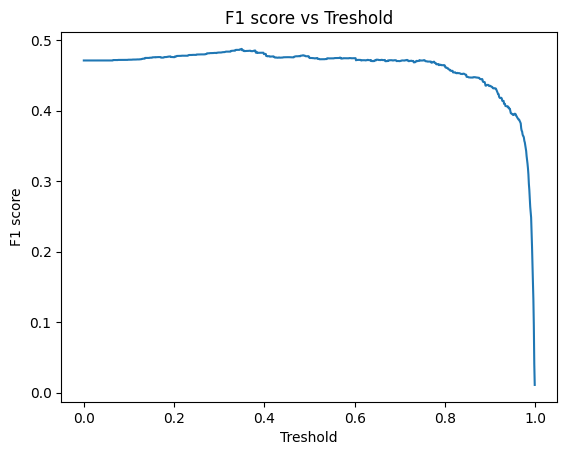

In [3]:
ps = []
rs = []
fs=[]
for fold in range(1,7):


    preds_pkl = f'/home/auguste/Desktop/bertax_training_2/berry/fold_{fold}/test_multi_predictions.pkl'
    preds_pkl = pd.read_pickle(preds_pkl)

    print("====================")
    print("fold",fold)

    X_ground_truth, X_preds = preds_pkl['data'][0][1], preds_pkl['data'][1][1]
    labels= np.argmax(X_ground_truth, axis=1)
    preds = np.argmax(X_preds, axis=1)

    p,r,f,s = prf(labels,preds,average='macro',labels=np.unique(labels),zero_division=0)
    ps.append(p)
    rs.append(r)
    fs.append(f)
    print('p',p,'r',r,'f',f)


    tresholds = np.arange(0,1,0.001)
    # find the best treshold
    prf_scores_tresh = np.zeros((len(tresholds), 3))
    for i,treshold in enumerate(tresholds):
        preds_tresh = preds.copy()
        preds_tresh[X_preds.max(axis=1) < treshold] = -1
        p,r,f,s = prf(labels, preds_tresh, average='macro', labels=np.unique(labels), zero_division=0)
        prf_scores_tresh[i, 0] = p
        prf_scores_tresh[i, 1] = r
        prf_scores_tresh[i, 2] = f
    arg_max = np.argmax(prf_scores_tresh[:,2])
    best_treshold = tresholds[arg_max]
    print('best treshold', best_treshold)
    print('best f1', np.max(prf_scores_tresh[:,2]) )
    print('best precision', prf_scores_tresh[arg_max,0])
    print('best recall', prf_scores_tresh[arg_max,1])

print(' Precision:', np.mean(ps))
print(' Recall:', np.mean(rs))
print(' F1:', np.mean(fs))

import matplotlib.pyplot as plt
plt.plot(tresholds, prf_scores_tresh[:,2])
plt.xlabel('Treshold')
plt.ylabel('F1 score')
plt.title('F1 score vs Treshold')
plt.show()

# Obitools 4.4.0

In [ ]:
import json
import csv


for fold in range(1,7):
    # Ouvre le fichier d'entrée
    with open(f"/home/auguste/Desktop/eDNA/TeleoClassification/scripts/Obitools/scripts/results/obi4/berry/fold_{fold}/test.ecotag", "r") as infile:
        lines = infile.readlines()

    # Variables temporaires
    records = []
    current_record = {}

    for line in lines:
        line = line.strip()
        if line.startswith(">"):
            # Sauvegarde l'ancien record si existant
            if current_record:
                records.append(current_record)
                current_record = {}

            # Sépare l'identifiant de la partie JSON
            header, metadata = line[1:].split(" ", 1)
            current_record["ID"] = header
            try:
                meta_dict = json.loads(metadata)
                for key, value in meta_dict.items():
                    current_record[key] = value
            except json.JSONDecodeError:
                print(f"Erreur de parsing JSON pour : {metadata}")
        elif line:
            # On assume que la séquence arrive en une seule ligne (ou on concatène sinon)
            current_record["sequence"] = current_record.get("sequence", "") + line

    # N'oublie pas d'ajouter le dernier record
    if current_record:
        records.append(current_record)

    # Détermine toutes les colonnes pour bien formater le CSV
    all_keys = set()
    for rec in records:
        all_keys.update(rec.keys())

    all_keys = sorted(all_keys)

    # Écriture du CSV
    with open(f"/home/auguste/Desktop/eDNA/TeleoClassification/scripts/Obitools/scripts/results/obi4/teleo/fold_{fold}/output.csv", "w", newline="") as outfile:
        writer = csv.DictWriter(outfile, fieldnames=all_keys)
        writer.writeheader()
        for rec in records:
            writer.writerow(rec)

    print("Conversion terminée.")

Conversion terminée.
Conversion terminée.
Conversion terminée.
Conversion terminée.
Conversion terminée.
Conversion terminée.


In [7]:

def get_family(x,database):

    sub = database[database['genus']== x]

    family = sub['family'].unique()

    if len(family) > 1:
        return 'NC_'
    return family[0]

for fold in range(1,7):

    preds = pd.read_csv(f'/home/auguste/Desktop/eDNA/TeleoClassification/scripts/Obitools/scripts/results/obi4/teleo/fold_{fold}/output.csv', sep=",")
    db = pd.read_csv(f'Obitools/scripts/data/teleo/folds/fold_{fold}/train.csv')
    labels = pd.read_csv(f'Obitools/scripts/data/teleo/folds/fold_{fold}/test.csv')

    preds['best_match']= preds['obitag_bestmatch'].apply(lambda x: '.'.join(x.split('.')[0:-1])) # remove the prefix

    preds['preds_family'] = preds['best_match'].apply(lambda x: get_family(x, db))

    preds['family_gt'] = labels['family']
    classes = labels['family'].unique()
    p, r, f, s = prf(preds["family_gt"], preds["preds_family"], average="macro", labels=classes, zero_division=0)
    print(f'Fold {fold} f1: {f}')
    print(f'Fold {fold} precision: {p}')
    print(f'Fold {fold} recall: {r}')
    preds = preds[['family_gt', 'preds_family', 'obitag_bestid']]
    # preds.to_csv(f'fold_{fold}_output_pred.csv', sep=",", index=False)
    print("--------------------------------")

Fold 1 f1: 0.48200755576399446
Fold 1 precision: 0.4714167182732313
Fold 1 recall: 0.5513764596569737
--------------------------------
Fold 2 f1: 0.4691688816977342
Fold 2 precision: 0.4545862181814489
Fold 2 recall: 0.5467574204652116
--------------------------------
Fold 3 f1: 0.47995057151573295
Fold 3 precision: 0.47017517857447116
Fold 3 recall: 0.5566811538558912
--------------------------------
Fold 4 f1: 0.486037450271905
Fold 4 precision: 0.4755576953692445
Fold 4 recall: 0.5649999012841648
--------------------------------
Fold 5 f1: 0.4689228239881885
Fold 5 precision: 0.4538135168492173
Fold 5 recall: 0.5441271200871262
--------------------------------
Fold 6 f1: 0.47295798961842717
Fold 6 precision: 0.46080478681659626
Fold 6 recall: 0.5437159586056645
--------------------------------


In [10]:

def get_family(x,database):

    sub = database[database['genus']== x]
    
    family = sub['family'].unique()
    
    if len(family) > 1:
        return 'NC_'
    return family[0]

def valid_rank(x):
    if x in ['family','subfamily', 'genus','subgenus','subspecies', 'species']:
        return True
    return False

marker = "teleo"

for fold in range(1,7):

    preds = pd.read_csv(f'Obitools/scripts/results/obi4/{marker}/fold_{fold}/output.csv', sep=",")
    db = pd.read_csv(f'Obitools/scripts/data/{marker}/folds/fold_{fold}/train.csv')
    labels = pd.read_csv(f'Obitools/scripts/data/{marker}/folds/fold_{fold}/test.csv')

    preds['best_match']= preds['obitag_bestmatch'].apply(lambda x: '.'.join(x.split('.')[0:-1])) # remove the prefix
    preds['preds_family'] = preds['best_match'].apply(lambda x: get_family(x, db))

    preds['obi_tag']= preds['taxid'].apply(lambda x: x.split('[')[1].split(']')[0]) # remove the prefix
    preds['valid_rank_preds'] = preds['obitag_rank'].apply(lambda x: valid_rank(x)) # remove the prefix

    preds['preds_family'] = preds.apply(lambda row: row['preds_family'] if row['valid_rank_preds'] else 'NC', axis=1)

    preds['family_gt'] = labels['family']
    classes = labels['family'].unique()
    p, r, f, s = prf(preds["family_gt"], preds["preds_family"], average="macro", labels=classes, zero_division=0)
    
    print(f'Fold {fold} precision: {p}')
    print(f'Fold {fold} recall: {r}')
    print(f'Fold {fold} f1: {f}')
    preds = preds[['family_gt', 'preds_family', 'obitag_bestid']]
    # preds.to_csv(f'fold_{fold}_output_pred.csv', sep=",", index=False)


    
    tresholds = np.arange(0,0.99,0.001)

    prf_scores_tresh = np.zeros((len(tresholds), 3))  # to store precision, recall, f1 for each treshold
    
    for i, treshold in enumerate(tresholds):
        score = preds['obitag_bestid'].apply(lambda x: 1 if x >= treshold else 0)
        preds['preds_family'] = preds['preds_family'].where(score == 1, 'NC')

        p, r, f, s = prf(preds["family_gt"], preds["preds_family"], average="macro", labels=classes, zero_division=0)
        prf_scores_tresh[i, 0] = p
        prf_scores_tresh[i, 1] = r
        prf_scores_tresh[i, 2] = f
    arg_max = np.argmax(prf_scores_tresh[:,2])
    best_treshold = tresholds[arg_max]
    print('best treshold', best_treshold)
    print('best f1', np.max(prf_scores_tresh[:,2]) )
    print('best precision', prf_scores_tresh[arg_max,0])
    print('best recall', prf_scores_tresh[arg_max,1])



    print("--------------------------------")

Fold 1 precision: 0.43772431272431267
Fold 1 recall: 0.38102147779060325
Fold 1 f1: 0.39125949521992526
best treshold 0.0
best f1 0.39125949521992526
best precision 0.43772431272431267
best recall 0.38102147779060325
--------------------------------
Fold 2 precision: 0.4448936353492293
Fold 2 recall: 0.40143662017386916
Fold 2 f1: 0.40798883764265026
best treshold 0.656
best f1 0.40803100504724654
best precision 0.4449870060308353
best recall 0.40143662017386916
--------------------------------
Fold 3 precision: 0.47870331828665164
Fold 3 recall: 0.42441981127423234
Fold 3 f1: 0.43091799874271874
best treshold 0.712
best f1 0.43157159351396057
best precision 0.479792642905388
best recall 0.42441981127423234
--------------------------------
Fold 4 precision: 0.46057834322540203
Fold 4 recall: 0.41959472196718467
Fold 4 f1: 0.421811318919275
best treshold 0.0
best f1 0.421811318919275
best precision 0.46057834322540203
best recall 0.41959472196718467
--------------------------------
Fold

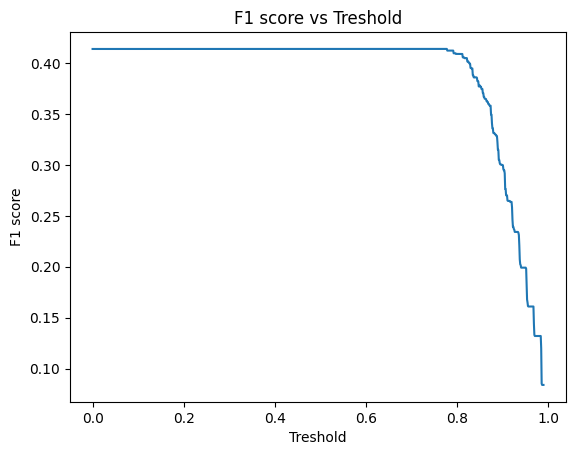

In [12]:
plt.plot(tresholds, prf_scores_tresh[:,2])
plt.xlabel('Treshold')
plt.ylabel('F1 score')
plt.title('F1 score vs Treshold')
plt.show()

# Ensemble : Obi4 classic + DnaBert


In [25]:

def get_family(x,database):

    sub = database[database['genus']== x]
    
    family = sub['family'].unique()

    if len(family) > 1:
        return 'NC_'
    return family[0]

def valid_rank(x):
    if x in ['family','subfamily', 'genus','subgenus','subspecies', 'species']:
        return True
    return False


for fold in range(1,7):

    preds_bert = pd.read_csv(f'DNABert2/experiments/fine_tune_taxa/outputs/teleo_from_mlm_no_cefe/checkpoints/fold_{fold}/predictions.csv')


    preds_obi = pd.read_csv(f'Obitools/scripts/results/obi4/teleo/fold_{fold}_output.csv', sep=",")
    db = pd.read_csv(f'Obitools/scripts/data/teleo/folds/fold_{fold}/train.csv')
    labels = pd.read_csv(f'Obitools/scripts/data/teleo/folds/fold_{fold}/test.csv')

    preds_obi['best_match']= preds_obi['obitag_bestmatch'].apply(lambda x: x.split('.')[0]) # remove the prefix
    preds_obi['preds_family'] = preds_obi['best_match'].apply(lambda x: get_family(x, db))

    preds_obi['obi_tag']= preds_obi['taxid'].apply(lambda x: x.split('[')[1].split(']')[0]) # remove the prefix
    preds_obi['valid_rank_preds'] = preds_obi['obitag_rank'].apply(lambda x: valid_rank(x)) # remove the prefix


    #choice preds_bert if not valid_rank_preds
    preds_obi['preds_family'] = preds_obi.apply(lambda row: row['preds_family'] if row['valid_rank_preds'] else preds_bert['preds_family_name'][row.name], axis=1)

    # preds['preds_family'] = preds.apply(lambda row: row['preds_family'] if row['valid_rank_preds'] else , axis=1)

    preds_obi['family_gt'] = labels['family']
    classes = labels['family'].unique()
    p, r, f, s = prf(preds_obi["family_gt"], preds_obi["preds_family"], average="macro", labels=classes, zero_division=0)
    print(f'Fold {fold} f1: {f}')
    print(f'Fold {fold} precision: {p}')
    print(f'Fold {fold} recall: {r}')
    preds = preds_obi[['family_gt', 'preds_family', 'obitag_bestid']]
    preds.to_csv(f'fold_{fold}_output_pred_ensemble_dnabert2.csv', sep=",", index=False)
    print("--------------------------------")

Fold 1 f1: 0.4956346703355422
Fold 1 precision: 0.4794261015293821
Fold 1 recall: 0.5662259640954032
--------------------------------
Fold 2 f1: 0.47202928857493337
Fold 2 precision: 0.4553985864928991
Fold 2 recall: 0.5575993137354633
--------------------------------
Fold 3 f1: 0.5073093094324904
Fold 3 precision: 0.4893076952712046
Fold 3 recall: 0.5850967126884183
--------------------------------
Fold 4 f1: 0.485577721222664
Fold 4 precision: 0.4681724608524479
Fold 4 recall: 0.5663985537684143
--------------------------------
Fold 5 f1: 0.495684414123275
Fold 5 precision: 0.4750196890451744
Fold 5 recall: 0.5808826719810863
--------------------------------
Fold 6 f1: 0.505226433146567
Fold 6 precision: 0.4897209688650607
Fold 6 recall: 0.5751957110004495
--------------------------------
